# Implementación del método de $K$-medias para segmentación de imagenes

### Importar librerías

In [9]:
import pandas as pd                # Manejo y análisis de estructuras de datos.
import numpy as np                 # Computo científico
import matplotlib.pyplot as plt    # Visualización

In [10]:
from PIL import Image               # Manejo de imágenes
from sklearn.cluster import KMeans  # Algoritmo de k-medias
from google.colab import drive      # Importar imágenes de google drive

### Definir funciones y variables

In [11]:
figsize = (7,7)

def Leer_Imagen(nombre):
    # Cargar imagen
    img = Image.open('/content/gdrive/My Drive/DataScience/'+nombre)
    # Transformar imagen
    I1 = np.asarray(img,dtype=np.float32)/255
    R, G, B = I1[:,:,0], I1[:,:,1],  I1[:,:,2]
    XR = R.reshape((-1, 1))
    XG = G.reshape((-1, 1))
    XB = B.reshape((-1, 1))
    X = np.concatenate((XR,XG,XB),axis=1)
    return I1, X

def Visualizar_Imagen(imagen):
    plt.figure(figsize=figsize)
    plt.imshow(imagen)
    plt.axis('off')
    plt.title("Imagen original")
    plt.show()
    plt.close()

def Visualizar_Particion_RGB(imagen, k_means):
    centroides = k_means.cluster_centers_
    etiquetas = k_means.labels_

    R, G, B = imagen[:,:,0], imagen[:,:,1],  imagen[:,:,2]
    XR = R.reshape((-1, 1))
    XG = G.reshape((-1, 1))
    XB = B.reshape((-1, 1))

    m = XR.shape
    for i in range(m[0]):
        XR[i] = centroides[etiquetas[i]][0]
        XG[i] = centroides[etiquetas[i]][1]
        XB[i] = centroides[etiquetas[i]][2]
    XR.shape = R.shape
    XG.shape = G.shape
    XB.shape = B.shape
    XR = XR[:, :, np.newaxis]
    XG = XG[:, :, np.newaxis]
    XB = XB[:, :, np.newaxis]
    Y = np.concatenate((XR,XG,XB),axis=2)
    plt.figure(figsize=figsize)
    plt.imshow(Y)
    plt.title(str(k_means.n_clusters)+" colores")
    plt.axis('off')
    plt.show()
    plt.close()

def Visualizar_Inercia(inercia):
    plt.figure(figsize=figsize)
    plt.scatter(x=inercia.keys(), y=inercia.values())
    plt.xlabel("No de clusters")
    plt.ylabel("Inercia")
    plt.show()
    plt.close()

def Visualizar_RGB(imagen):
  R, G, B = imagen[:,:,0], imagen[:,:,1],  imagen[:,:,2]
  R.flatten()
  fig = plt.figure(figsize=(7,7))
  ax = fig.add_subplot(projection='3d')
  ax.scatter(R.flatten(), G.flatten(), B.flatten(), marker=".", s=10)
  ax.set_xlabel("Red")
  ax.set_ylabel("Blue")
  ax.set_zlabel("Green")
  plt.show()
  plt.close()

def Imagen_KMeans(nombre, k):
  imagen, rgb = Leer_Imagen(nombre)
  Visualizar_RGB(imagen)
  Visualizar_Imagen(imagen)
  k_means = KMeans(n_clusters=k, n_init=1, init="random")
  k_means.fit(rgb)
  Visualizar_Particion_RGB(imagen, k_means)

### Leer los datos


In [12]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


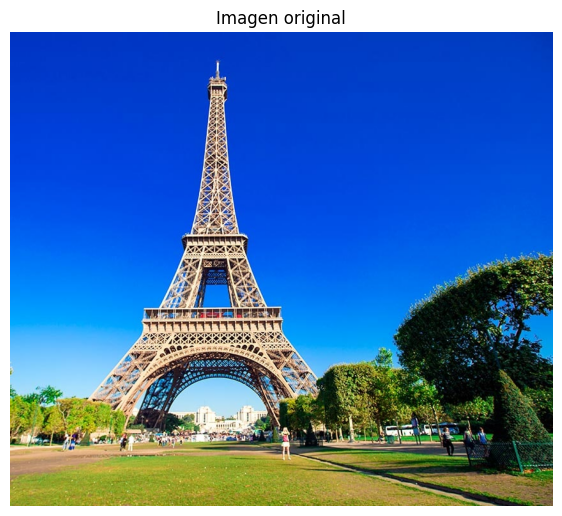

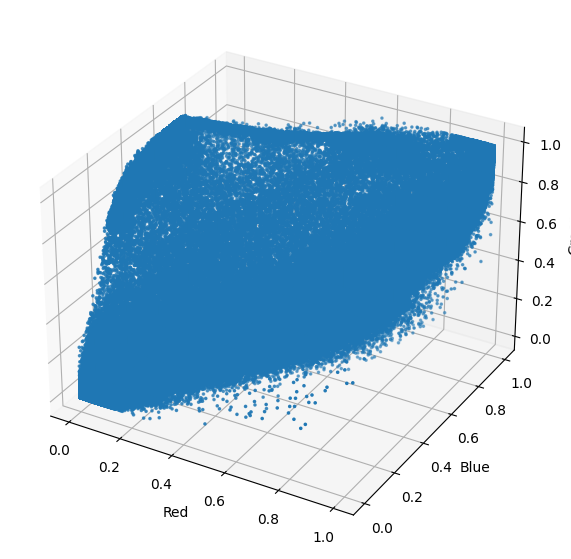

In [13]:
imagen, rgb = Leer_Imagen("torre.jpg")
Visualizar_Imagen(imagen)
Visualizar_RGB(imagen)

# Implementación del algoritmo **k-medias**

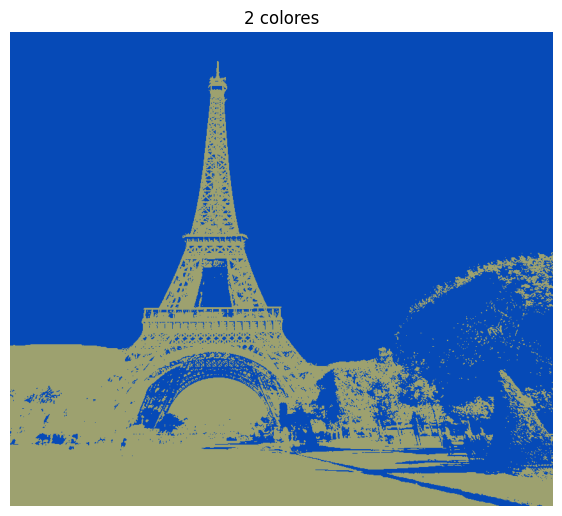

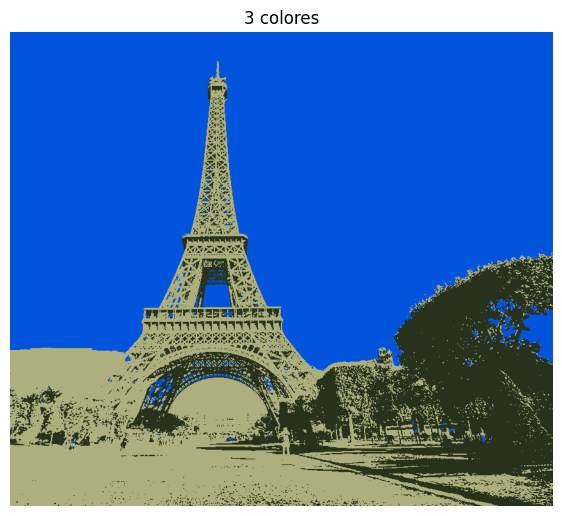

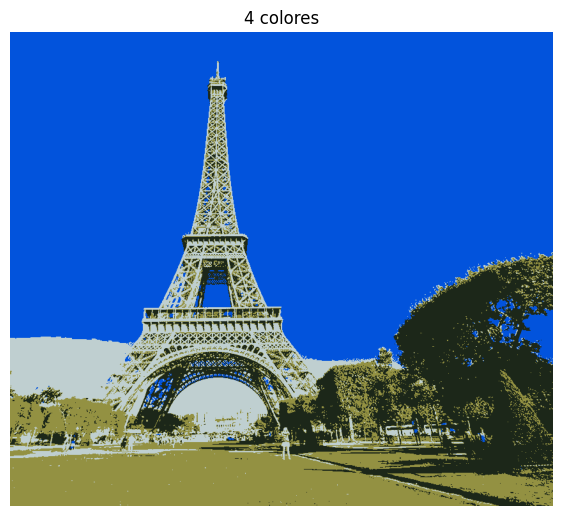

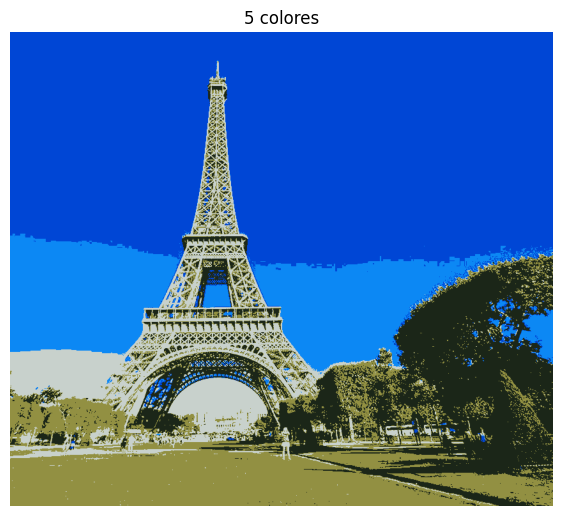

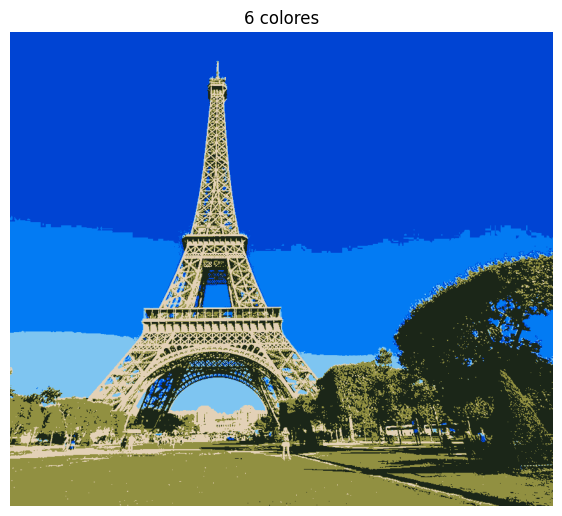

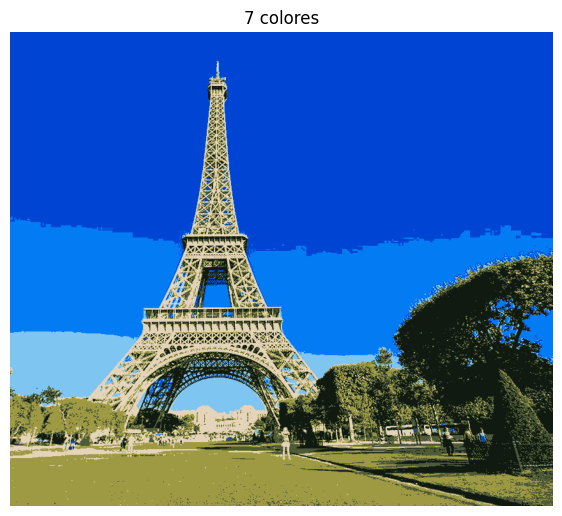

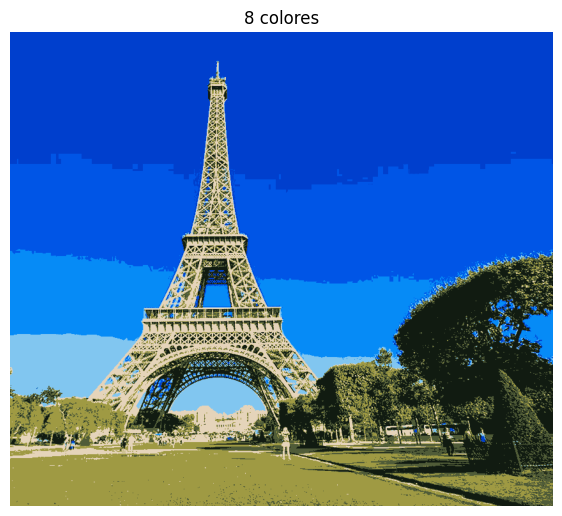

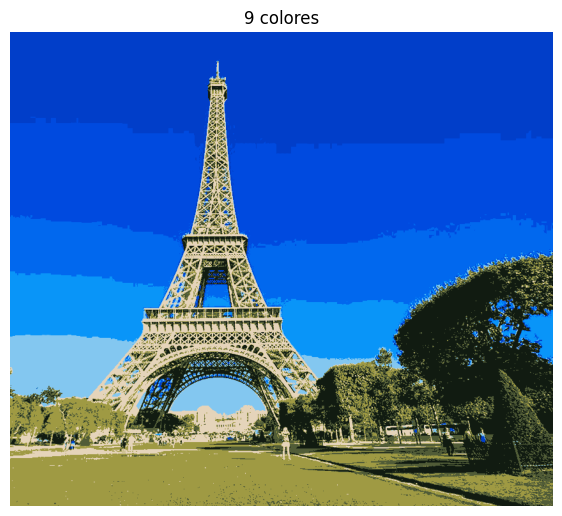

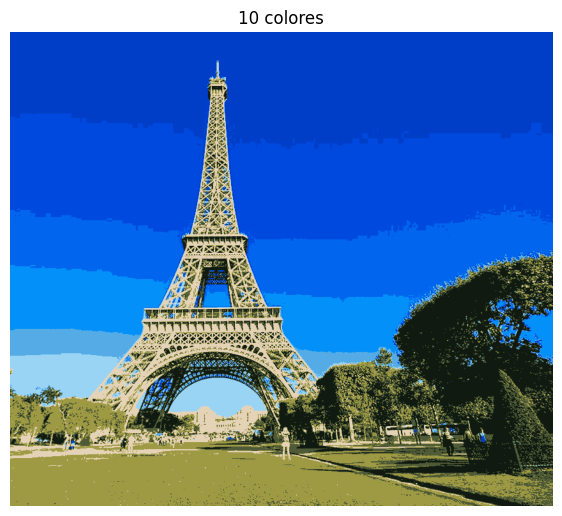

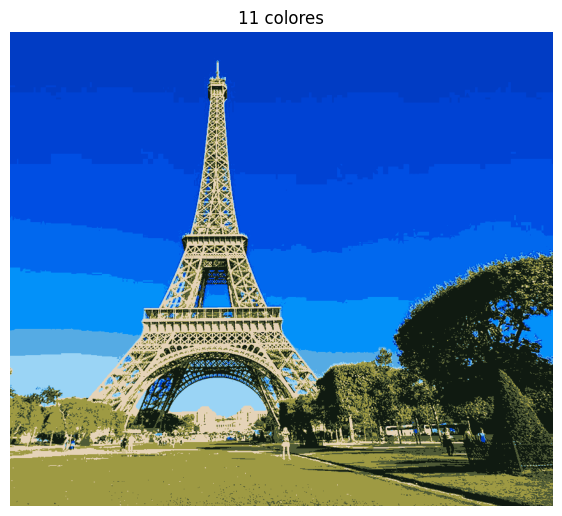

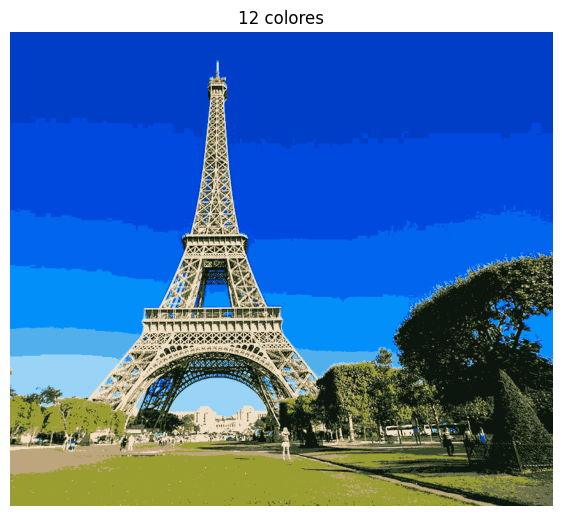

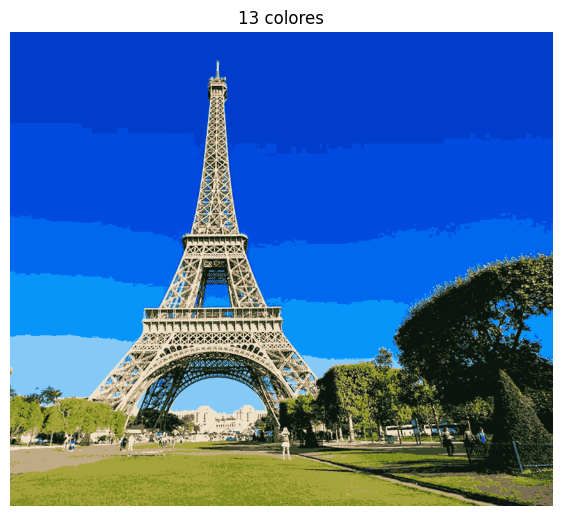

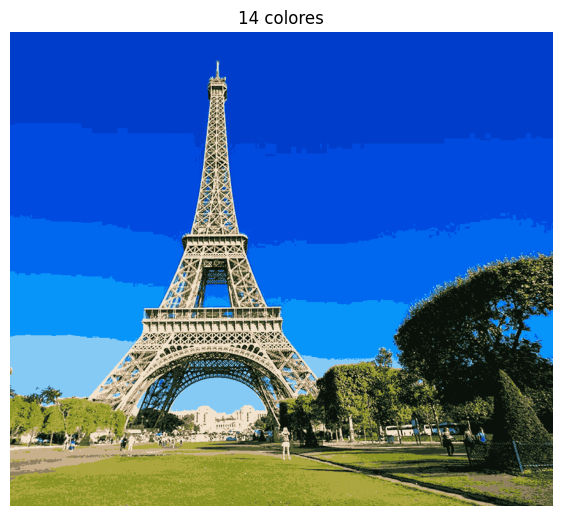

In [14]:
rango_k = range(2,15)
inertia = {}

for k in rango_k:
    # Crear una instancia del modelo
    k_means = KMeans(n_clusters=k, n_init=1, init="random")
    # Ajustar los datos
    k_means.fit(rgb)
    # Visualizar
    Visualizar_Particion_RGB(imagen, k_means)
    # Calcular inercia
    inertia[k] = k_means.inertia_

# Método de *Elbow* para seleccionar el $k$ adecuado

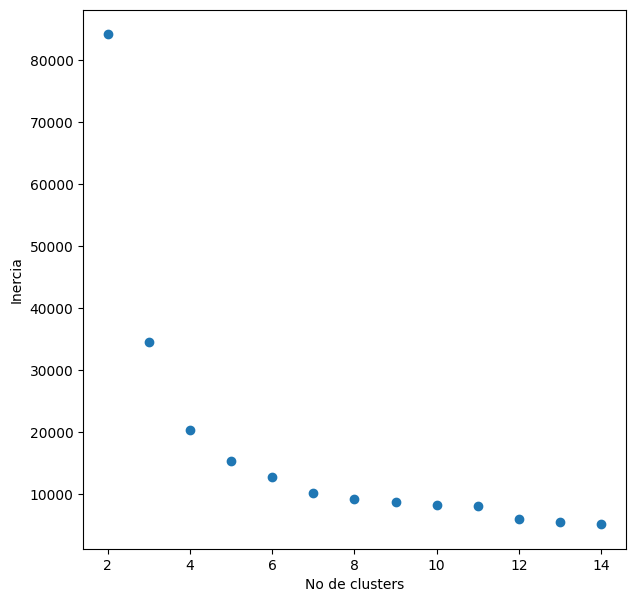

In [15]:
Visualizar_Inercia(inertia)

# Otros ejemplos

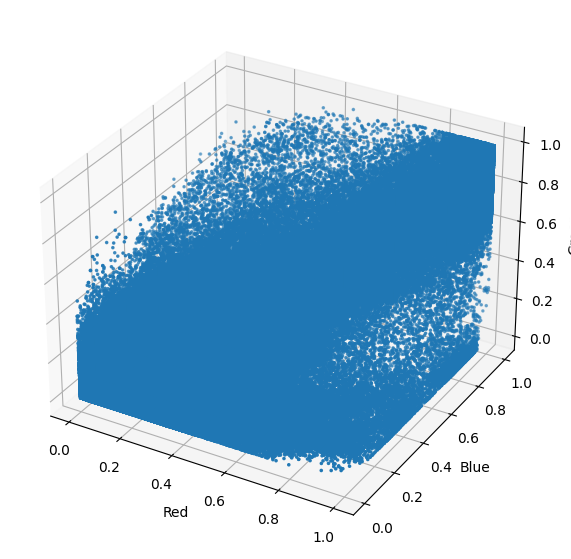

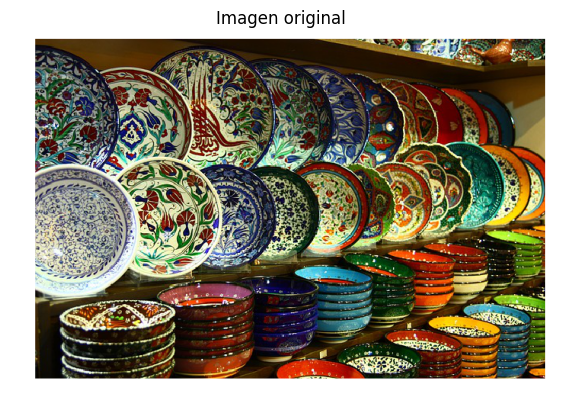

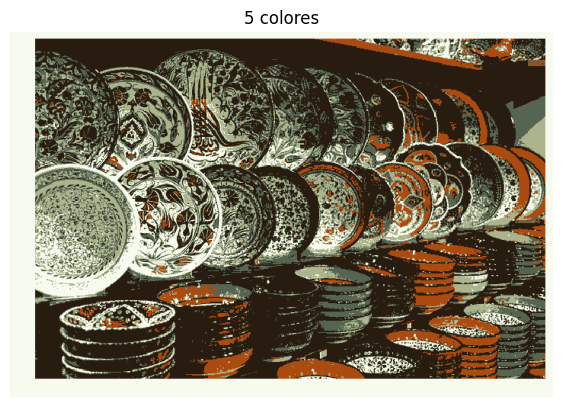

In [16]:
Imagen_KMeans("tienda.png", 5)

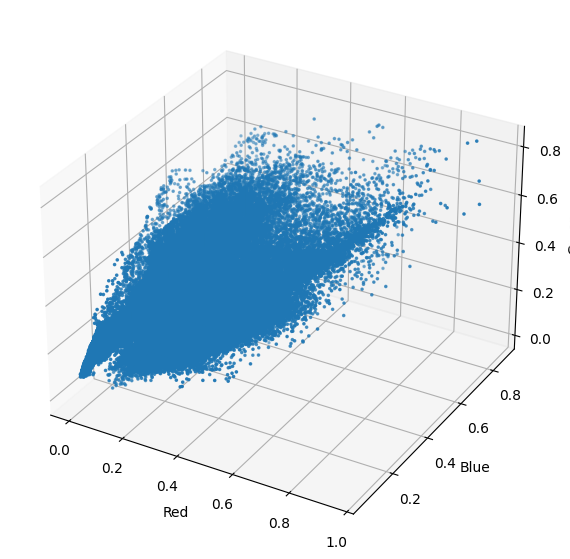

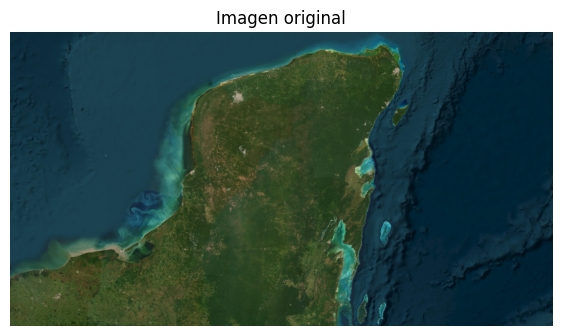

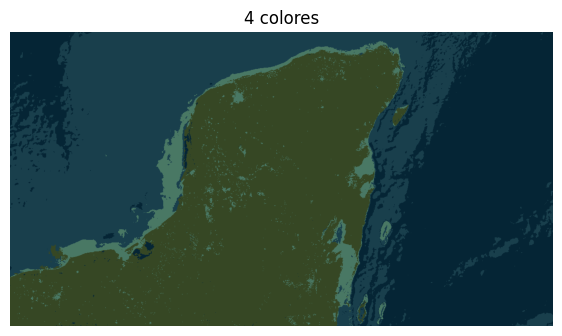

In [19]:
Imagen_KMeans("Yucatan.png", 4)

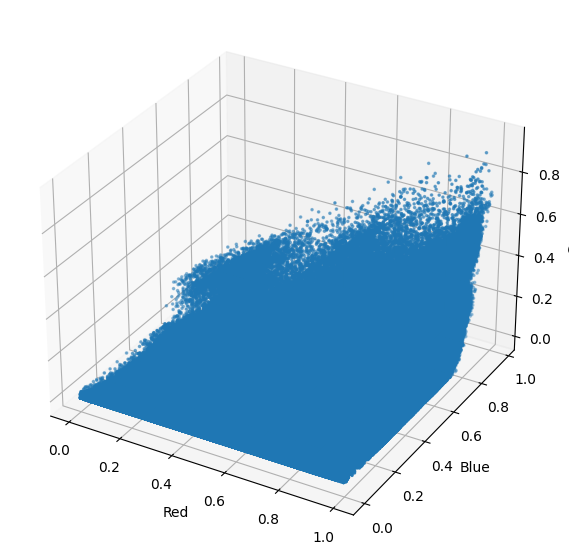

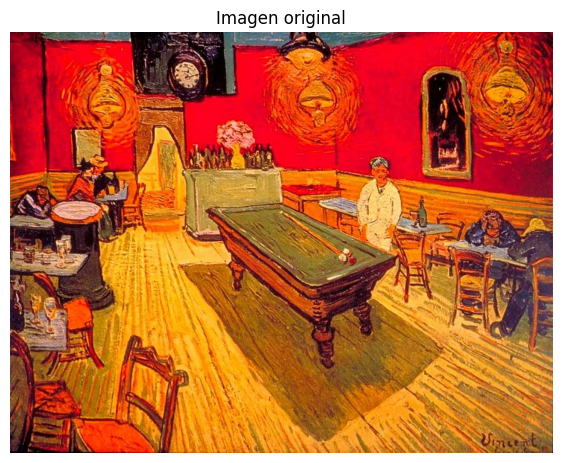

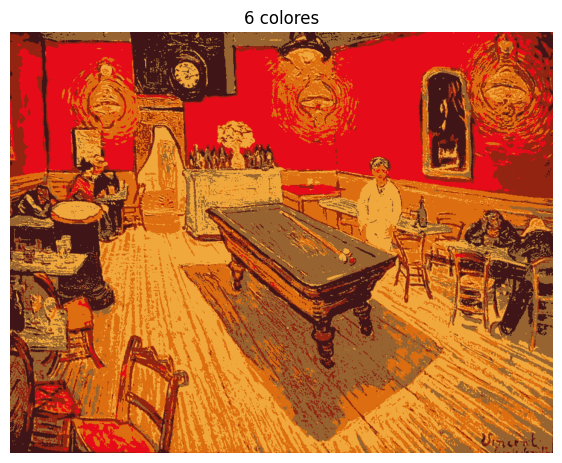

In [24]:
Imagen_KMeans("VanGogh.jpg", 6)